# 02 Preprocessing

Executable reporting notebook for preprocessing, keyword relabeling, aspect taxonomy derivation, weak aspect labeling, and refinement quality control. It reads generated outputs and figures without training SVM or IndoBERT.


## CRISP-DM Stage

Data Preparation. This notebook verifies generated preprocessing outputs and documents limitations before model training.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "CLAUDE.md").exists() and (candidate / "ml-service").exists():
            return candidate
    raise RuntimeError("Could not find SentiRank project root from current working directory.")


PROJECT_ROOT = find_project_root()
ML_SERVICE_DIR = PROJECT_ROOT / "ml-service"
DATASETS_DIR = PROJECT_ROOT / "datasets"
DOCS_FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"


def load_json(path: Path):
    if not path.exists():
        display(Markdown(f"Missing JSON: `{path.relative_to(PROJECT_ROOT)}`"))
        return None
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def load_csv(path: Path, **kwargs):
    if not path.exists():
        display(Markdown(f"Missing CSV: `{path.relative_to(PROJECT_ROOT)}`"))
        return None
    return pd.read_csv(path, **kwargs)


def show_json_as_table(payload, title: str):
    if payload is None:
        return
    display(Markdown(f"### {title}"))
    try:
        table = pd.json_normalize(payload, sep=".").T.reset_index()
        table.columns = ["field", "value"]
        display(table)
    except Exception as exc:
        display(Markdown(f"Could not tabulate JSON payload: `{exc}`"))
        display(payload)


def show_csv_preview(path: Path, title: str, rows: int = 10):
    data = load_csv(path)
    if data is None:
        return None
    display(Markdown(f"### {title}"))
    display(data.head(rows))
    if len(data) > rows:
        display(Markdown(f"Rows: `{len(data)}`. Showing first `{rows}` rows."))
    return data


def show_figures(figure_paths: list[Path], title: str):
    display(Markdown(f"## {title}"))
    shown = 0
    for figure_path in figure_paths:
        if figure_path.exists():
            display(Markdown(f"**{figure_path.relative_to(PROJECT_ROOT)}**"))
            display(Image(filename=str(figure_path)))
            shown += 1
        else:
            display(Markdown(f"Missing figure: `{figure_path.relative_to(PROJECT_ROOT)}`"))
    if shown == 0:
        display(Markdown("No figures were available to display."))

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank


## Reproducible Pipeline Commands

The commands below are the reproducible preprocessing entrypoints. They are displayed by default. Setting `RUN_PREPROCESSING_PIPELINE = True` will execute them and regenerate ignored processed datasets, so keep it disabled unless intentionally rerunning preprocessing.


In [2]:
import subprocess
import sys

PREPROCESSING_COMMANDS = [
    [sys.executable, "scripts/relabel_by_keywords.py", "--input", "../datasets/raw/reviews_raw_labeled.csv", "--output", "../datasets/processed/reviews_relabelled.csv"],
    [sys.executable, "scripts/preprocess_indobert.py", "--input", "../datasets/processed/reviews_relabelled.csv", "--output", "../datasets/processed/reviews_preprocessed_indobert.csv"],
    [sys.executable, "scripts/preprocess_svm.py", "--input", "../datasets/processed/reviews_preprocessed_indobert.csv", "--output", "../datasets/processed/reviews_preprocessed_svm.csv"],
    [sys.executable, "scripts/derive_aspect_taxonomy.py", "--input", "../datasets/processed/reviews_final.csv", "--output-summary", "../datasets/outputs/eda/02_preprocessing/aspect_taxonomy_derivation_summary.json", "--output-keywords", "../datasets/outputs/eda/02_preprocessing/aspect_taxonomy_candidate_terms.csv"],
    [sys.executable, "scripts/label_aspects_by_keywords.py", "--input", "../datasets/processed/reviews_final.csv", "--output", "../datasets/processed/reviews_with_aspect_labels_refined.csv", "--summary-output", "../datasets/outputs/eda/02_preprocessing/aspect_labeling_refined_summary.json"],
]

for command in PREPROCESSING_COMMANDS:
    display(Markdown("```bash\n" + " ".join(command) + "\n```"))

RUN_PREPROCESSING_PIPELINE = False
if RUN_PREPROCESSING_PIPELINE:
    for command in PREPROCESSING_COMMANDS:
        result = subprocess.run(command, cwd=ML_SERVICE_DIR, text=True, capture_output=True, check=False)
        print("$ " + " ".join(command))
        print(result.stdout)
        if result.stderr:
            print(result.stderr)
        if result.returncode != 0:
            raise RuntimeError(f"Command failed with return code {result.returncode}")
else:
    display(Markdown("Preprocessing commands were not executed. This notebook is in reporting mode."))


```bash
c:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\ml-service\.venv\Scripts\python.exe scripts/relabel_by_keywords.py --input ../datasets/raw/reviews_raw_labeled.csv --output ../datasets/processed/reviews_relabelled.csv
```

```bash
c:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\ml-service\.venv\Scripts\python.exe scripts/preprocess_indobert.py --input ../datasets/processed/reviews_relabelled.csv --output ../datasets/processed/reviews_preprocessed_indobert.csv
```

```bash
c:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\ml-service\.venv\Scripts\python.exe scripts/preprocess_svm.py --input ../datasets/processed/reviews_preprocessed_indobert.csv --output ../datasets/processed/reviews_preprocessed_svm.csv
```

```bash
c:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\ml-service\.venv\Scripts\python.exe scripts/derive_aspect_taxonomy.py --input ../datasets/processed/reviews_final.csv --output-summary ../datasets/outputs/eda/02_preprocessing/aspect_taxonomy_derivation_summary.json --output-keywords ../datasets/outputs/eda/02_preprocessing/aspect_taxonomy_candidate_terms.csv
```

```bash
c:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\ml-service\.venv\Scripts\python.exe scripts/label_aspects_by_keywords.py --input ../datasets/processed/reviews_final.csv --output ../datasets/processed/reviews_with_aspect_labels_refined.csv --summary-output ../datasets/outputs/eda/02_preprocessing/aspect_labeling_refined_summary.json
```

Preprocessing commands were not executed. This notebook is in reporting mode.

## Load Preprocessing Summaries

The notebook reads relabeling, preprocessing, taxonomy, and aspect-label quality summaries from `datasets/outputs/eda/02_preprocessing/`.


In [3]:
EDA02_DIR = DATASETS_DIR / "outputs" / "eda" / "02_preprocessing"
summary_paths = {
    "Relabeling summary": EDA02_DIR / "relabeling_summary.json",
    "Preprocessing summary": EDA02_DIR / "preprocessing_summary.json",
    "Aspect taxonomy derivation summary": EDA02_DIR / "aspect_taxonomy_derivation_summary.json",
    "Aspect labeling summary": EDA02_DIR / "aspect_labeling_summary.json",
    "Refined aspect labeling summary": EDA02_DIR / "aspect_labeling_refined_summary.json",
    "General fallback analysis": EDA02_DIR / "general_fallback_analysis.json",
}

preprocessing_summaries = {name: load_json(path) for name, path in summary_paths.items()}
for name, payload in preprocessing_summaries.items():
    show_json_as_table(payload, name)


### Relabeling summary

,field,value
0,audit_candidate_count,6853
1,changed_label_count,10153
2,changed_label_percentage,10.3833
3,generated_at,2026-05-14T11:27:32.086300+00:00
4,rating_3_changed_count,10153
5,total_rows,97782
6,label_distribution_after.Negative,39686
7,label_distribution_after.Neutral,17629
8,label_distribution_after.Positive,40467
9,label_distribution_before.Negative,35000


### Preprocessing summary

,field,value
0,empty_text_indobert_count,0
1,empty_text_svm_count,91
2,generated_at,2026-05-14T11:27:56.906230+00:00
3,label_column,final_sentiment
4,missing_source_text_count,0
5,total_rows,97782
6,label_distribution_final.Negative,39686
7,label_distribution_final.Neutral,17629
8,label_distribution_final.Positive,40467


### Aspect taxonomy derivation summary

...

,field,value
0,general_label_count,46704
1,general_label_percentage,47.7634
2,generated_at,2026-05-14T12:11:31.669480+00:00
3,methodology_note,Weak aspect labels are generated using keyword...
4,rows_with_keyword_match,51078
5,rows_without_keyword_match,46704
6,total_rows,97782
7,aspect_distribution.Account/Login,1555
8,aspect_distribution.Ads Experience,16540
9,aspect_distribution.Audio Quality,435


### Refined aspect labeling summary

,field,value
0,general_label_count,44267
1,general_label_percentage,45.2711
2,generated_at,2026-05-14T12:34:57.949622+00:00
3,methodology_note,Refined weak aspect labels include keyword sco...
4,rows_with_keyword_match,53515
5,rows_without_keyword_match,44267
6,total_rows,97782
7,aspect_distribution.Account/Login,1474
8,aspect_distribution.Ads Experience,16282
9,aspect_distribution.Audio Quality,442


### General fallback analysis

,field,value
0,general_negative_rows,11453
1,general_neutral_rows,10410
2,general_percentage,47.7634
3,general_rows,46704
4,generated_at,2026-05-14T12:32:54.850739+00:00
5,methodology_note,General fallback rows are analyzed to identify...
6,top_general_bigrams,"[{'count': 1076, 'term': 'sangat bagus'}, {'co..."
7,top_general_terms,"[{'count': 10288, 'term': 'bagus'}, {'count': ..."
8,total_rows,97782


## Metric Tables

These aggregate CSV/JSON files are suitable for thesis tables and future dashboard visualization.


In [4]:
metric_files = [
    "label_distribution_before_relabeling.csv",
    "label_distribution_after_relabeling.csv",
    "text_length_before_after_cleaning.csv",
    "aspect_label_distribution.csv",
    "aspect_label_distribution_refined.csv",
    "aspect_by_sentiment_distribution.csv",
    "aspect_by_sentiment_distribution_refined.csv",
    "aspect_label_confidence_distribution.csv",
    "aspect_taxonomy_candidate_terms.csv",
    "general_fallback_terms.csv",
]

loaded_eda02_tables = {}
for filename in metric_files:
    table = show_csv_preview(EDA02_DIR / filename, filename, rows=15)
    if table is not None:
        loaded_eda02_tables[filename] = table

for filename in [
    "label_distribution_before_relabeling.json",
    "label_distribution_after_relabeling.json",
    "text_length_before_after_cleaning.json",
    "aspect_label_distribution_refined.json",
    "aspect_label_confidence_distribution.json",
]:
    show_json_as_table(load_json(EDA02_DIR / filename), filename)


### label_distribution_before_relabeling.csv

,sentiment_label,count
0,Negative,35000
1,Neutral,27782
2,Positive,35000


### label_distribution_after_relabeling.csv

,sentiment_label,count
0,Negative,39686
1,Neutral,17629
2,Positive,40467


### text_length_before_after_cleaning.csv

...

Could not tabulate JSON payload: `Length mismatch: Expected axis has 9 elements, new values have 2 elements`

[{'aspect_label': 'Performance & Stability', 'count': 2600},
 {'aspect_label': 'Ads Experience', 'count': 16282},
 {'aspect_label': 'Subscription & Pricing', 'count': 10663},
 {'aspect_label': 'Features & Content', 'count': 21703},
 {'aspect_label': 'Audio Quality', 'count': 442},
 {'aspect_label': 'UI/UX', 'count': 351},
 {'aspect_label': 'Account/Login', 'count': 1474},
 {'aspect_label': 'General', 'count': 44267}]

### aspect_label_confidence_distribution.json

Could not tabulate JSON payload: `Length mismatch: Expected axis has 5 elements, new values have 2 elements`

[{'aspect_label_confidence': 'none', 'count': 44267},
 {'aspect_label_confidence': 'low', 'count': 36532},
 {'aspect_label_confidence': 'medium', 'count': 9811},
 {'aspect_label_confidence': 'high', 'count': 7172}]

## Preprocessing and Aspect Figures

Figures are loaded from `docs/figures/02_preprocessing/`.


## Preprocessing Figures

**docs\figures\02_preprocessing\label_distribution_before_relabeling.png**

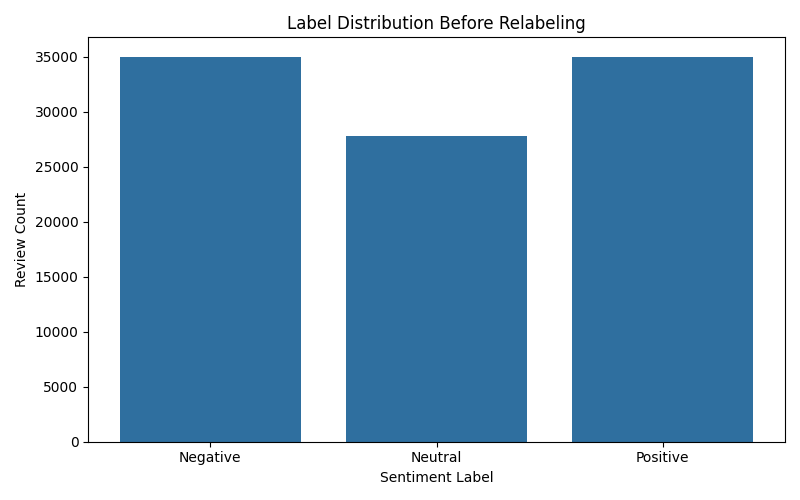

**docs\figures\02_preprocessing\label_distribution_after_relabeling.png**

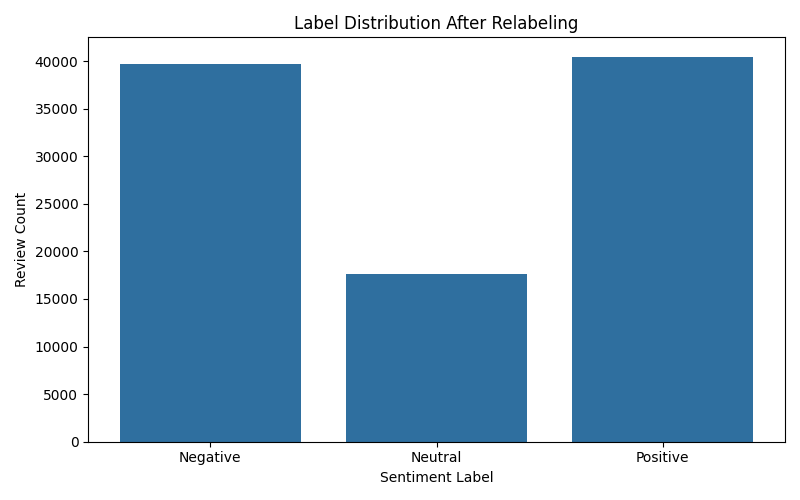

**docs\figures\02_preprocessing\relabeling_change_summary.png**

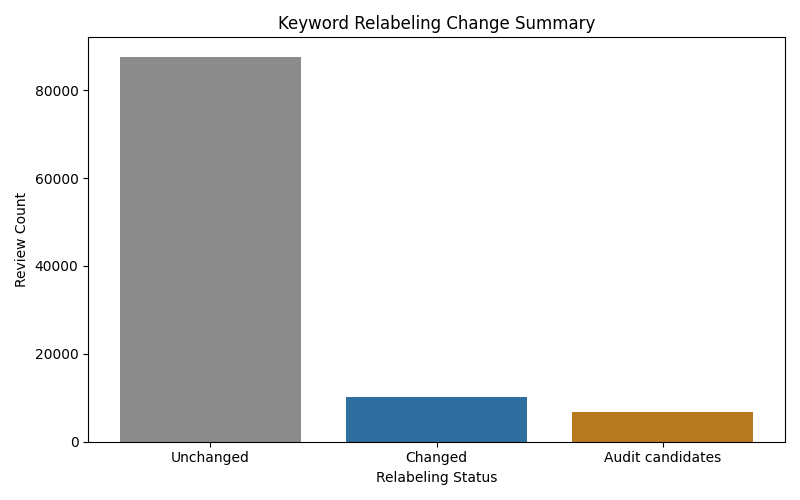

**docs\figures\02_preprocessing\text_length_before_after_cleaning.png**

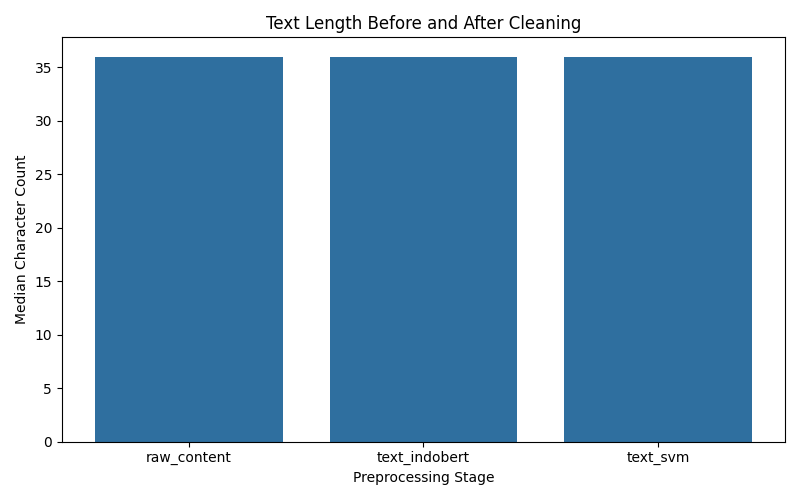

**docs\figures\02_preprocessing\aspect_candidate_terms.png**

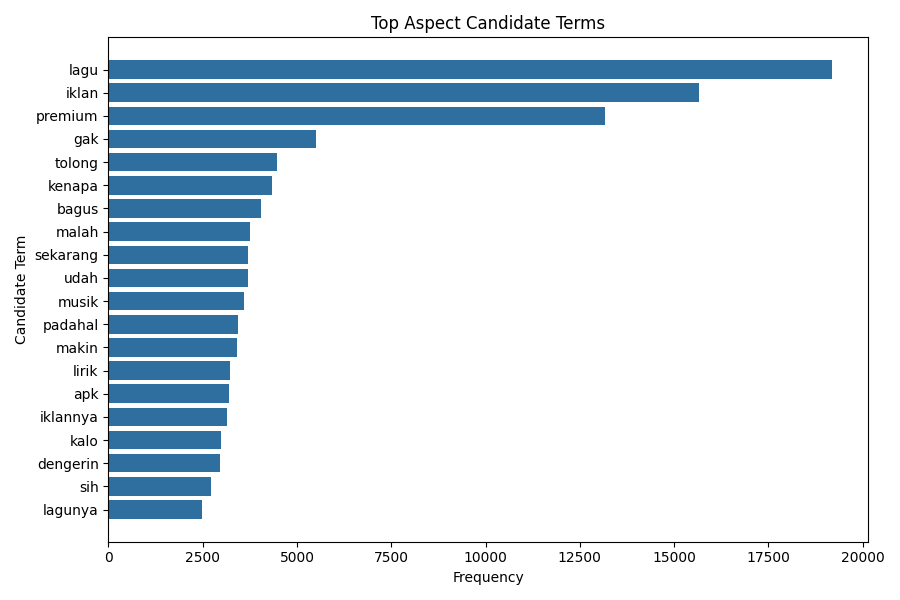

**docs\figures\02_preprocessing\aspect_label_distribution.png**

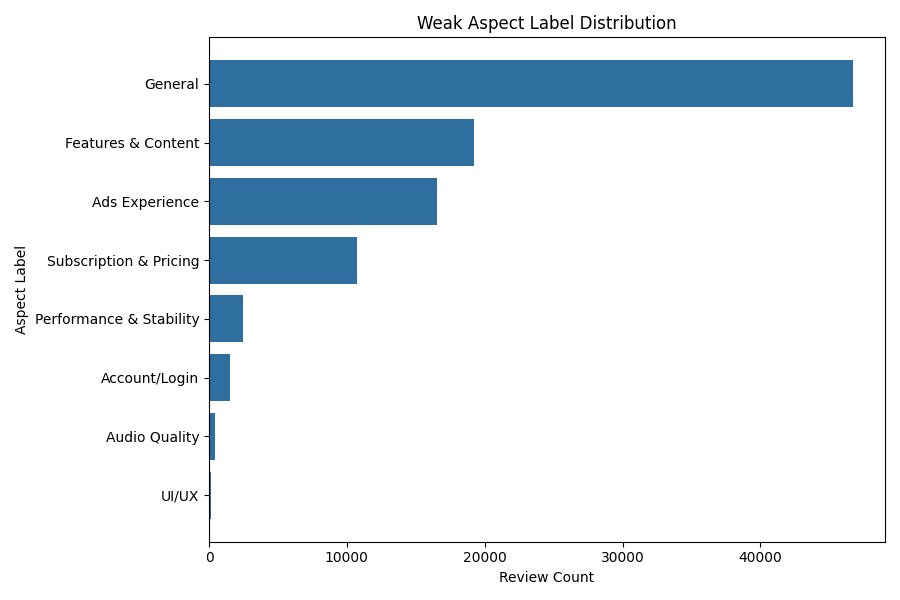

**docs\figures\02_preprocessing\aspect_by_sentiment_distribution.png**

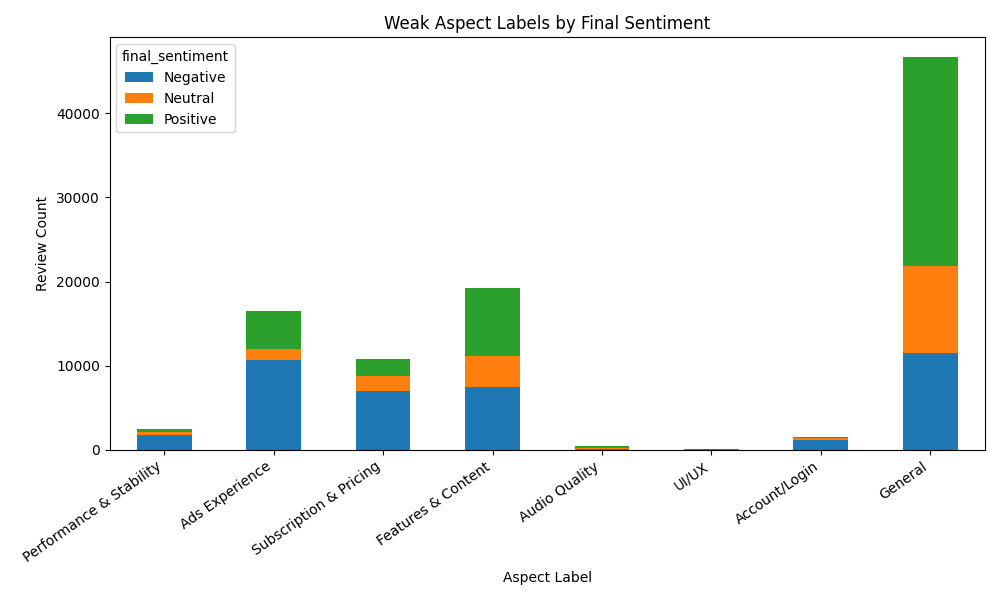

**docs\figures\02_preprocessing\aspect_label_distribution_refined.png**

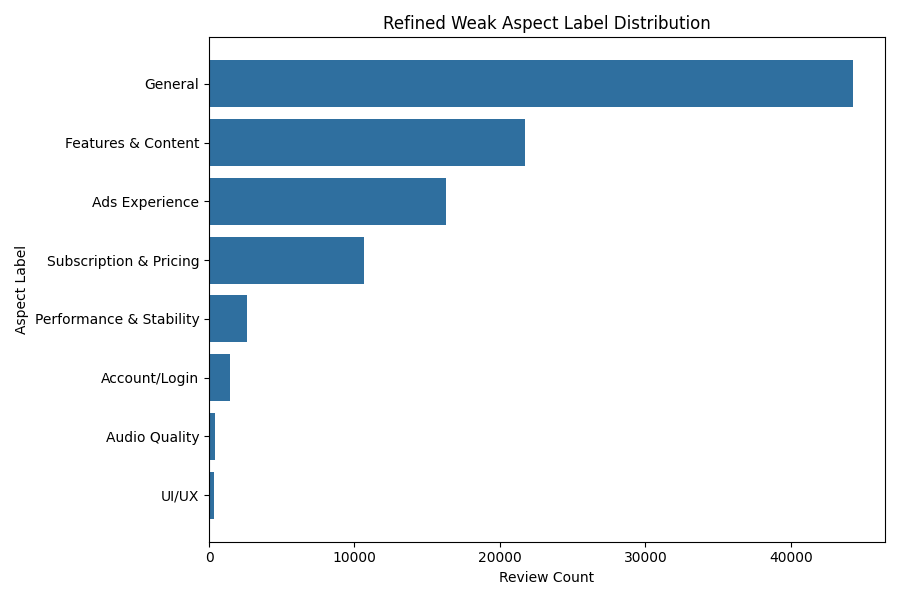

**docs\figures\02_preprocessing\aspect_by_sentiment_distribution_refined.png**

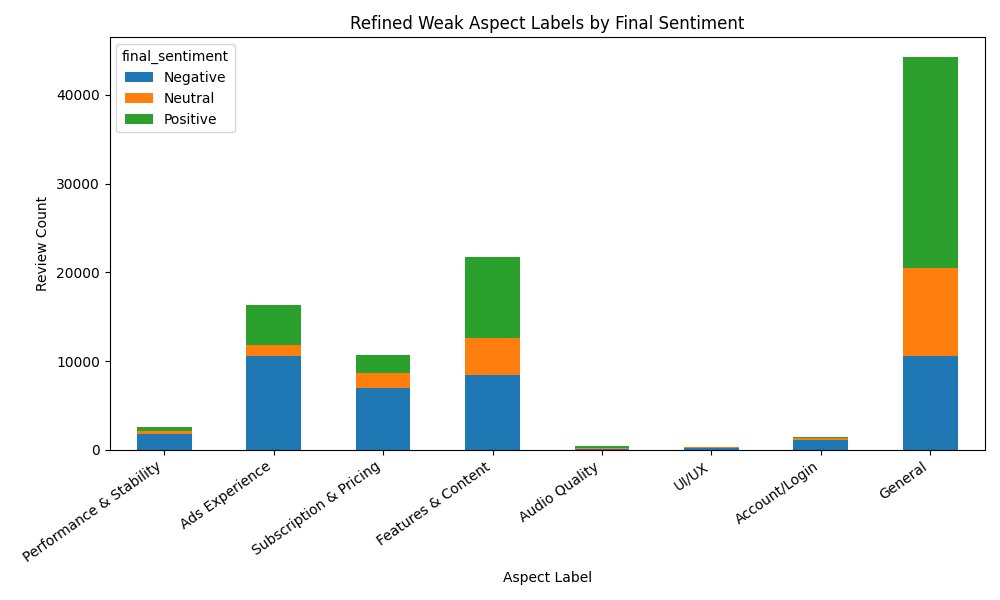

**docs\figures\02_preprocessing\aspect_label_confidence_distribution.png**

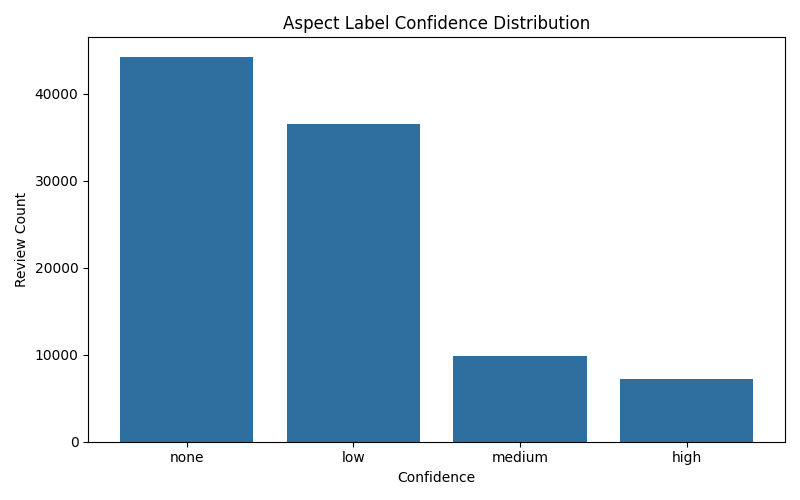

**docs\figures\02_preprocessing\general_fallback_top_terms.png**

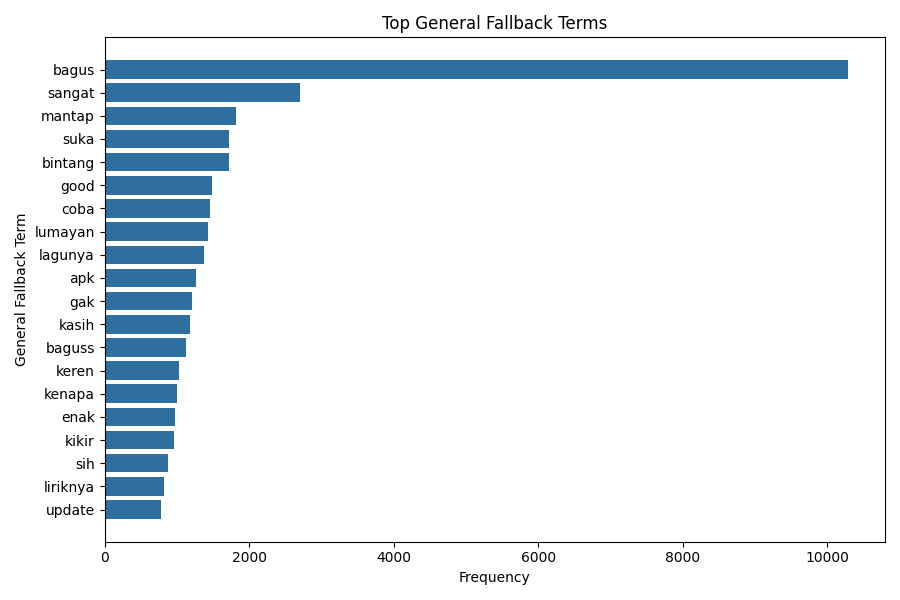

**docs\figures\02_preprocessing\general_rate_before_after.png**

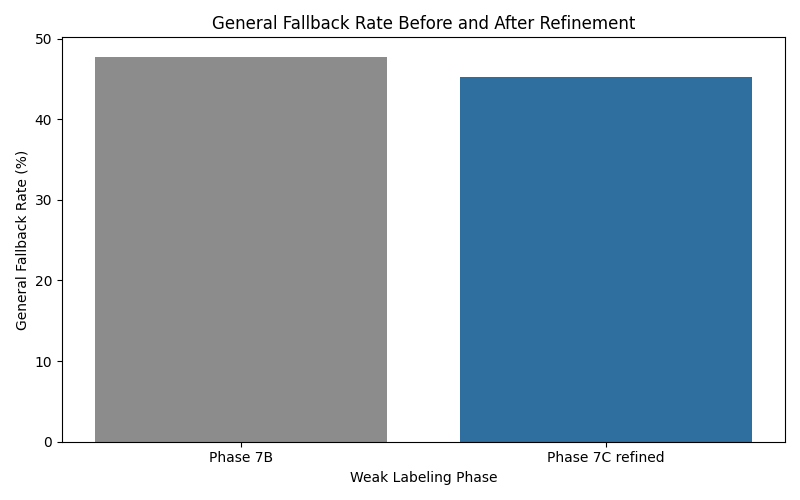

In [5]:
FIG02_DIR = DOCS_FIGURES_DIR / "02_preprocessing"
figure_files = [
    "label_distribution_before_relabeling.png",
    "label_distribution_after_relabeling.png",
    "relabeling_change_summary.png",
    "text_length_before_after_cleaning.png",
    "aspect_candidate_terms.png",
    "aspect_label_distribution.png",
    "aspect_by_sentiment_distribution.png",
    "aspect_label_distribution_refined.png",
    "aspect_by_sentiment_distribution_refined.png",
    "aspect_label_confidence_distribution.png",
    "general_fallback_top_terms.png",
    "general_rate_before_after.png",
]
show_figures([FIG02_DIR / filename for filename in figure_files], "Preprocessing Figures")


## Interpretation Notes

This cell turns the generated summaries into thesis-facing notes.


In [6]:
notes = []

relabel = preprocessing_summaries.get("Relabeling summary") or {}
if relabel:
    changed_count = relabel.get("changed_label_count")
    changed_pct = relabel.get("changed_label_percentage")
    notes.append(f"Keyword relabeling changed `{changed_count}` rows (`{changed_pct:.4f}%`) while preserving `initial_sentiment`.")
    before = relabel.get("label_distribution_before")
    after = relabel.get("label_distribution_after")
    if before and after:
        notes.append(f"Label distribution before relabeling: `{before}`; after relabeling: `{after}`.")

preprocess = preprocessing_summaries.get("Preprocessing summary") or {}
if preprocess:
    notes.append(f"Preprocessing summary fields available: `{list(preprocess.keys())}`.")

aspect_summary = preprocessing_summaries.get("Aspect labeling summary") or {}
refined_summary = preprocessing_summaries.get("Refined aspect labeling summary") or {}
if aspect_summary:
    notes.append(f"Initial weak aspect General fallback rate: `{aspect_summary.get('general_label_percentage')}`%.")
if refined_summary:
    notes.append(f"Refined weak aspect General fallback rate: `{refined_summary.get('general_label_percentage')}`%.")
    notes.append(f"Rows with keyword match after refinement: `{refined_summary.get('rows_with_keyword_match')}`.")

confidence = loaded_eda02_tables.get("aspect_label_confidence_distribution.csv")
if confidence is not None:
    notes.append("Aspect confidence distribution is available; later SVM training should prioritize high/medium confidence labels or a balanced refined subset.")

notes.append("The aspect taxonomy is exploratory and weak-labeled. It is not expert-validated ground truth and must not be used directly as final AHP/Fuzzy AHP criteria.")
notes.append("`General` is a fallback label only, not a decision criterion for AHP/Fuzzy AHP.")
notes.append("Next steps: use `03_indobert_sentiment_modeling.ipynb` for final sentiment model selection and `04_svm_aspect_classification.ipynb` later for aspect classifier training.")

display(Markdown("\n".join(f"- {note}" for note in notes)))


- Keyword relabeling changed `10153` rows (`10.3833%`) while preserving `initial_sentiment`.
- Label distribution before relabeling: `{'Negative': 35000, 'Neutral': 27782, 'Positive': 35000}`; after relabeling: `{'Negative': 39686, 'Neutral': 17629, 'Positive': 40467}`.
- Preprocessing summary fields available: `['empty_text_indobert_count', 'empty_text_svm_count', 'generated_at', 'label_column', 'label_distribution_final', 'missing_source_text_count', 'total_rows']`.
- Initial weak aspect General fallback rate: `47.7634`%.
- Refined weak aspect General fallback rate: `45.2711`%.
- Rows with keyword match after refinement: `53515`.
- Aspect confidence distribution is available; later SVM training should prioritize high/medium confidence labels or a balanced refined subset.
- The aspect taxonomy is exploratory and weak-labeled. It is not expert-validated ground truth and must not be used directly as final AHP/Fuzzy AHP criteria.
- `General` is a fallback label only, not a decision criterion for AHP/Fuzzy AHP.
- Next steps: use `03_indobert_sentiment_modeling.ipynb` for final sentiment model selection and `04_svm_aspect_classification.ipynb` later for aspect classifier training.